# Notebook 01 — Exploratory Data Analysis

**Objective:** Understand the structure, distributions, and quirks of `profiles.csv`
before writing any preprocessing code. Every decision made in `02_preprocessing.ipynb`
is justified by an observation made here.

**What this notebook does NOT do:**
- It does not permanently drop any columns
- It does not modify the dataset on disk
- It does not build any features

`df_original` loaded here is kept intact throughout.

Cell 2 — Imports


In [1]:
import os
import sys

# Walk up from notebooks/ to the project root
NOTEBOOK_DIR = os.path.abspath("")
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)

# Add project root to path so src/ is importable
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root : {PROJECT_ROOT}")
print(f"src exists   : {os.path.isdir(os.path.join(PROJECT_ROOT, 'src'))}")
print(f"data exists  : {os.path.isdir(os.path.join(PROJECT_ROOT, 'data'))}")

Project root : /Users/yugjain/Documents/ML_ASS/unsupervised-professional-matching
src exists   : True
data exists  : True


## 1. Load & Initial Inspection

Load the raw CSV and immediately print structural information.
The first priority is confirming there is no label leakage from `compatibility_pairs.csv`, as it would defeat the purpose of unsupervised learning.

In [2]:
import ast
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    RAW_DATA_PATH, PLOTS_DIR,
    PII_COLS, DROP_COLS, AST_COLS,
    SENIORITY_ORDER, N_SKILLS
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.bbox"] = "tight"
warnings.filterwarnings("ignore")

# Confirm the data file is actually reachable
print(f"Data file path : {RAW_DATA_PATH}")
print(f"File exists    : {os.path.isfile(RAW_DATA_PATH)}")
print(f"Plots dir      : {PLOTS_DIR}")

Data file path : /Users/yugjain/Documents/ML_ASS/unsupervised-professional-matching/data/raw/profiles.csv
File exists    : True
Plots dir      : /Users/yugjain/Documents/ML_ASS/unsupervised-professional-matching/outputs/plots


## 1. Load & Initial Inspection

In [3]:
df_original = pd.read_csv(RAW_DATA_PATH)

print(f"Shape : {df_original.shape[0]:,} rows × {df_original.shape[1]} columns")
print(f"\nColumns:\n{df_original.columns.tolist()}")
print(f"\nDtypes:\n{df_original.dtypes}")

Shape : 50,000 rows × 20 columns

Columns:
['profile_id', 'name', 'email', 'current_role', 'current_company', 'industry', 'years_experience', 'seniority_level', 'skills', 'experience', 'education', 'connections', 'goals', 'needs', 'can_offer', 'location', 'remote_preference', 'headline', 'about', 'source']

Dtypes:
profile_id            object
name                  object
email                 object
current_role          object
current_company       object
industry              object
years_experience     float64
seniority_level       object
skills                object
experience            object
education             object
connections            int64
goals                 object
needs                 object
can_offer             object
location              object
remote_preference     object
headline              object
about                 object
source                object
dtype: object


# checking for label leakage 

Making sure that any explicit labelled columns that indicate compatibility between profiles are omitted

In [4]:
leakage_keywords = ["compat", "score", "label", "target", "match", "rating"]
leakage_cols = [
    c for c in df_original.columns
    if any(k in c.lower() for k in leakage_keywords)
]

if leakage_cols:
    print(f" WARNING — potential leakage columns: {leakage_cols}")
else:
    print(" No label leakage detected in profiles.csv")
    print(" compatibility_pairs.csv is never loaded in this pipeline")

 No label leakage detected in profiles.csv
 compatibility_pairs.csv is never loaded in this pipeline


## Null summary

In [5]:
null_summary = pd.DataFrame({
    "null_count": df_original.isnull().sum(),
    "null_pct":   (df_original.isnull().mean() * 100).round(2),
    "dtype":      df_original.dtypes,
    "n_unique":   df_original.nunique(),
    "sample":     [
        str(df_original[c].dropna().iloc[0])[:80]
        if df_original[c].notna().any() else "ALL NULL"
        for c in df_original.columns
    ]
}).sort_values("null_pct", ascending=False)

print(null_summary.to_string())

                   null_count  null_pct    dtype  n_unique                                                                            sample
profile_id                  0       0.0   object     50000                                                                        PROF-00001
name                        0       0.0   object      1600                                                                    Thomas Johnson
about                       0       0.0   object     33281                              Experienced data engineer with 11.3 years in energy.
headline                    0       0.0   object       480                                                           Data Engineer at Amazon
remote_preference           0       0.0   object         3                                                                            onsite
location                    0       0.0   object       760                                                              San Antonio, Germany
can_offer    

## 2. JSON Field Inspection

These columns are stored as Python literal strings using single quotes.
`json.loads()` will raise an error on them — `ast.literal_eval()` is required.

We inspect 3 real rows of each field to confirm the exact internal
structure before writing any parsing logic in notebook 02.

In [6]:
def safe_parse(val):
    """
    Parse a field stored as a Python literal string.
    Uses ast.literal_eval — NOT json.loads — because values
    use single quotes which are invalid JSON syntax.
    Returns None if parsing fails or value is null.
    """
    if pd.isna(val):
        return None
    if isinstance(val, (list, dict)):
        return val
    try:
        return ast.literal_eval(val)
    except Exception:
        return None


def inspect_field(df, col, n=3):
    print(f"\n{'='*60}")
    print(f"Column  : '{col}'")
    print(f"Nulls   : {df[col].isna().mean()*100:.1f}%")
    print(f"{'='*60}")
    for i, val in df[col].dropna().head(n).items():
        parsed = safe_parse(val)
        print(f"\n  Row {i}:")
        print(f"    Raw type    : {type(val).__name__}")
        print(f"    Parsed type : {type(parsed).__name__}")
        print(f"    Value       : {parsed}")


for col in AST_COLS:
    inspect_field(df_original, col, n=3)


Column  : 'skills'
Nulls   : 0.0%

  Row 0:
    Raw type    : str
    Parsed type : list
    Value       : ['python', 'plc', 'machine learning', 'c++', 'automation', 'quantitative analysis', 'matlab', 'scada', 'power systems', 'lean manufacturing']

  Row 1:
    Raw type    : str
    Parsed type : list
    Value       : ['mongodb', 'risk assessment', 'lms', 'marketing', 'moodle']

  Row 2:
    Raw type    : str
    Parsed type : list
    Value       : ['seo', 'tableau', 'cad']

Column  : 'experience'
Nulls   : 0.0%

  Row 0:
    Raw type    : str
    Parsed type : list
    Value       : [{'title': 'Frontend Developer', 'company': 'Apple', 'duration': '18 months'}, {'title': 'CTO', 'company': 'McKinsey', 'duration': '6 months'}, {'title': 'CTO', 'company': 'Meta', 'duration': '24 months'}, {'title': 'Frontend Developer', 'company': 'Adobe', 'duration': '24 months'}, {'title': 'Scrum Master', 'company': 'Google', 'duration': '3 years'}]

  Row 1:
    Raw type    : str
    Parsed type : 

## 3. Univariate Analysis

One plot per modelling-relevant column.
All figures are saved to `outputs/plots/` for direct use in the presentation.
Columns in `DROP_COLS` and `PII_COLS` are excluded from analysis.

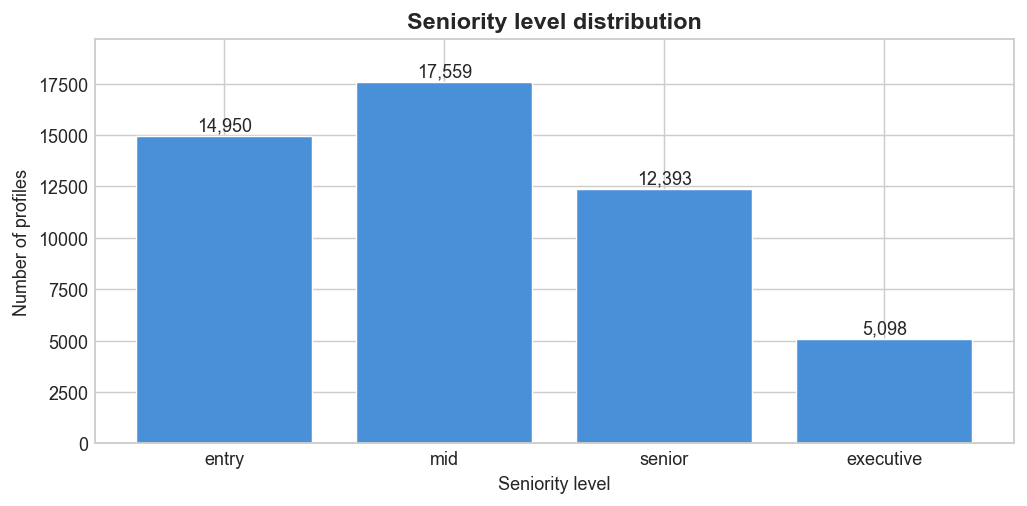

seniority_level
entry        14950
mid          17559
senior       12393
executive     5098


In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

counts = df_original["seniority_level"].value_counts()
ordered = counts.reindex([s for s in SENIORITY_ORDER if s in counts.index])

bars = ax.bar(ordered.index, ordered.values,
              color="#4A90D9", edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, ordered.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 80,
            f"{val:,}", ha="center", va="bottom", fontsize=10)

ax.set_title("Seniority level distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Seniority level")
ax.set_ylabel("Number of profiles")
ax.set_ylim(0, ordered.max() * 1.12)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "01_seniority_distribution.png"))
plt.show()
print(ordered.to_string())

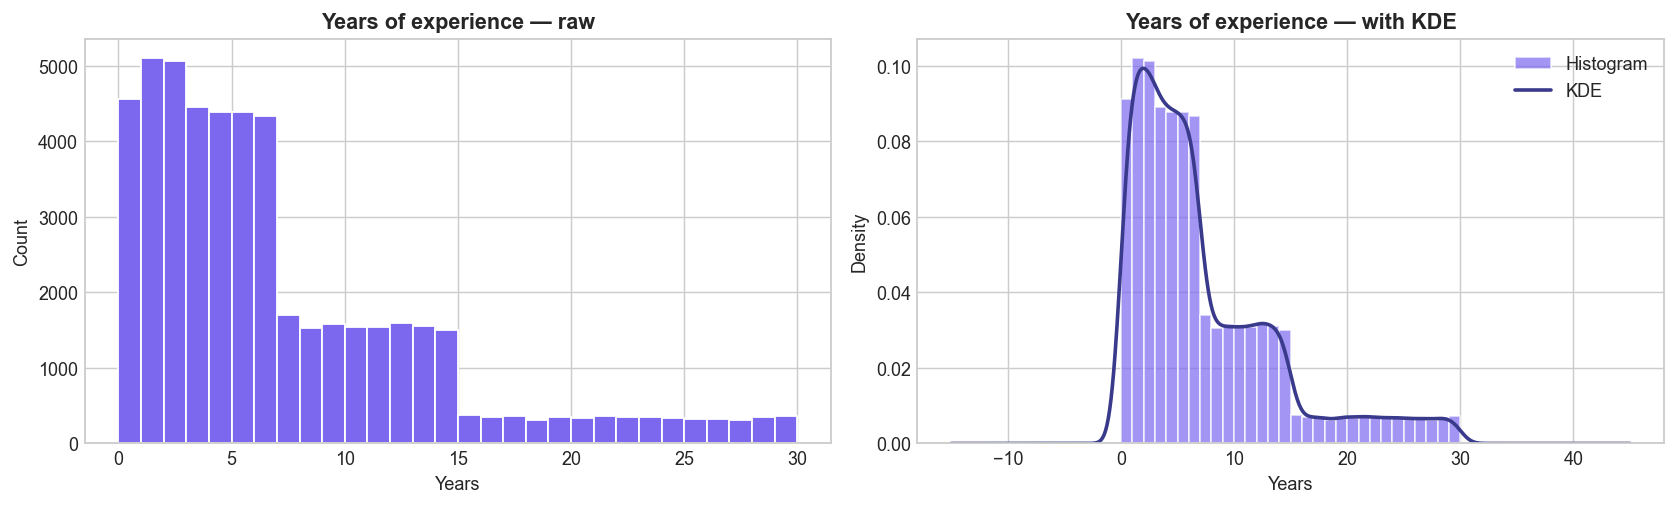

count    50000.00
mean         7.22
std          6.53
min          0.00
25%          2.50
50%          5.30
75%         10.20
max         30.00
Name: years_experience, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df_original["years_experience"].plot(
    kind="hist", bins=30, ax=axes[0],
    color="#7B68EE", edgecolor="white"
)
axes[0].set_title("Years of experience — raw", fontweight="bold")
axes[0].set_xlabel("Years")
axes[0].set_ylabel("Count")

df_original["years_experience"].plot(
    kind="hist", bins=30, ax=axes[1],
    color="#7B68EE", edgecolor="white",
    density=True, alpha=0.7, label="Histogram"
)
df_original["years_experience"].plot(
    kind="kde", ax=axes[1], color="#3A3A8C", linewidth=2, label="KDE"
)
axes[1].set_title("Years of experience — with KDE", fontweight="bold")
axes[1].set_xlabel("Years")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "02_experience_distribution.png"))
plt.show()
print(df_original["years_experience"].describe().round(2))

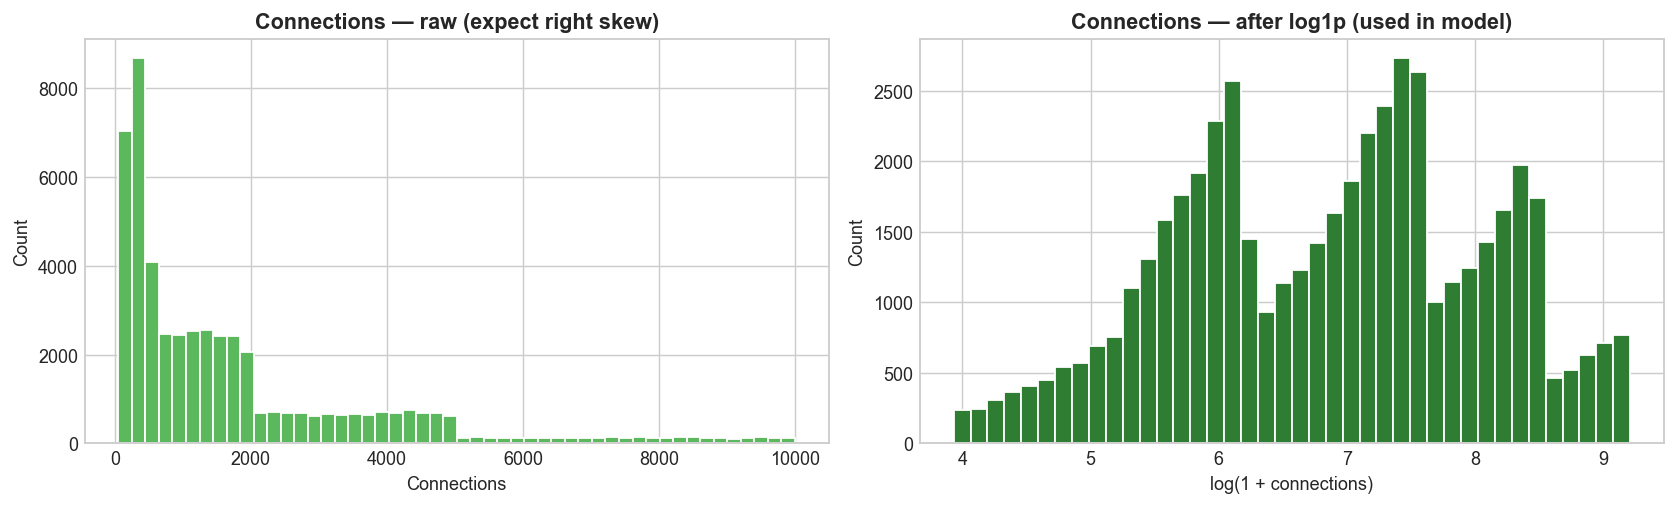

count    50000.00
mean      1766.77
std       1994.53
min         50.00
25%        374.00
50%       1066.50
75%       2274.25
max       9999.00
Name: connections, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df_original["connections"].plot(
    kind="hist", bins=50, ax=axes[0],
    color="#5CB85C", edgecolor="white"
)
axes[0].set_title("Connections — raw (expect right skew)", fontweight="bold")
axes[0].set_xlabel("Connections")
axes[0].set_ylabel("Count")

np.log1p(df_original["connections"]).plot(
    kind="hist", bins=40, ax=axes[1],
    color="#2E7D32", edgecolor="white"
)
axes[1].set_title("Connections — after log1p (used in model)", fontweight="bold")
axes[1].set_xlabel("log(1 + connections)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "03_connections_distribution.png"))
plt.show()
print(df_original["connections"].describe().round(2))

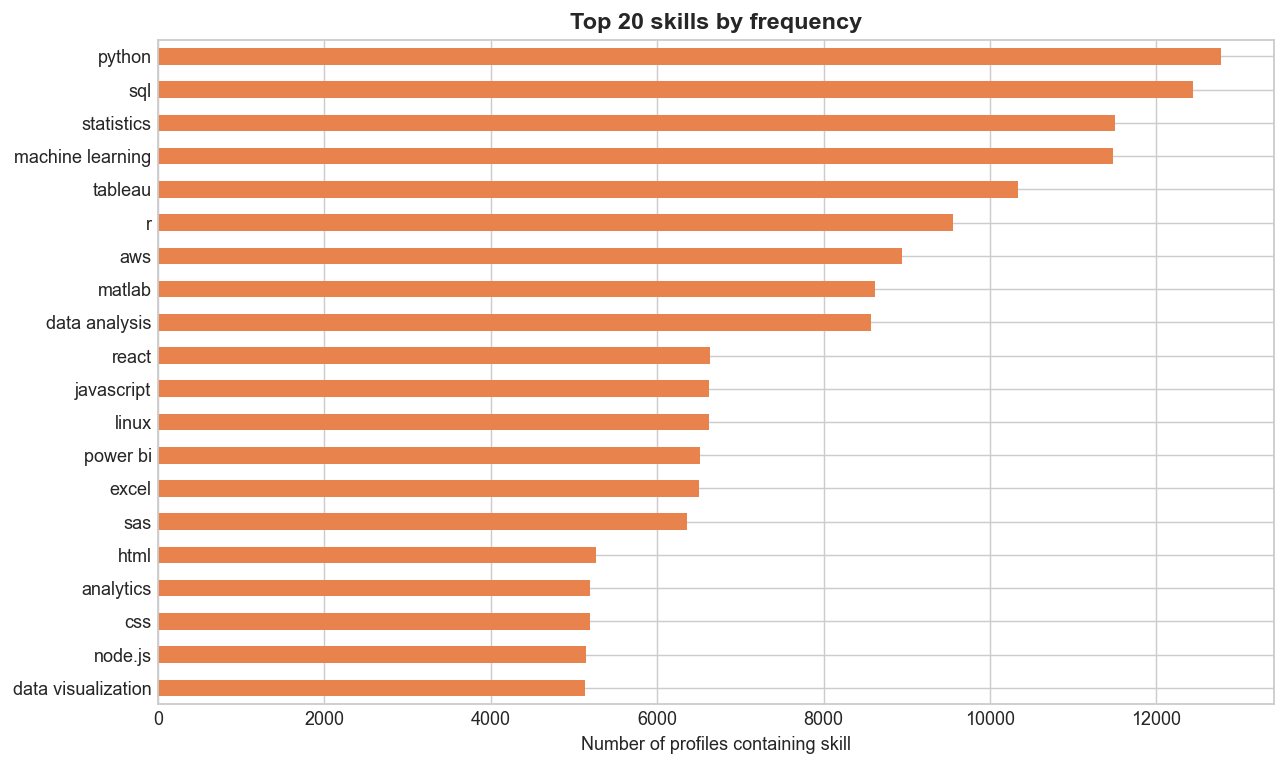

Total unique skills      : 101
Total skill mentions     : 348,751
Avg skills per profile   : 7.0
Top 100 skill coverage  : 346,941 / 348,751 (99.5% of all mentions)


In [10]:
all_skills = []
for val in df_original["skills"].dropna():
    parsed = safe_parse(val)
    if isinstance(parsed, list):
        seen = set()
        for s in parsed:
            if isinstance(s, str):
                clean = s.strip().lower()
                if clean and clean not in seen:
                    all_skills.append(clean)
                    seen.add(clean)

skill_counts = Counter(all_skills)
top20 = pd.DataFrame(skill_counts.most_common(20), columns=["skill", "count"])

fig, ax = plt.subplots(figsize=(10, 6))
top20.sort_values("count").plot(
    kind="barh", x="skill", y="count",
    ax=ax, color="#E8834E", legend=False
)
ax.set_title("Top 20 skills by frequency", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of profiles containing skill")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "04_top_skills.png"))
plt.show()

top_n_coverage = sum(v for _, v in skill_counts.most_common(N_SKILLS))
total_mentions = len(all_skills)
print(f"Total unique skills      : {len(skill_counts):,}")
print(f"Total skill mentions     : {total_mentions:,}")
print(f"Avg skills per profile   : "
      f"{total_mentions / df_original['skills'].notna().sum():.1f}")
print(f"Top {N_SKILLS} skill coverage  : "
      f"{top_n_coverage:,} / {total_mentions:,} "
      f"({100*top_n_coverage/total_mentions:.1f}% of all mentions)")

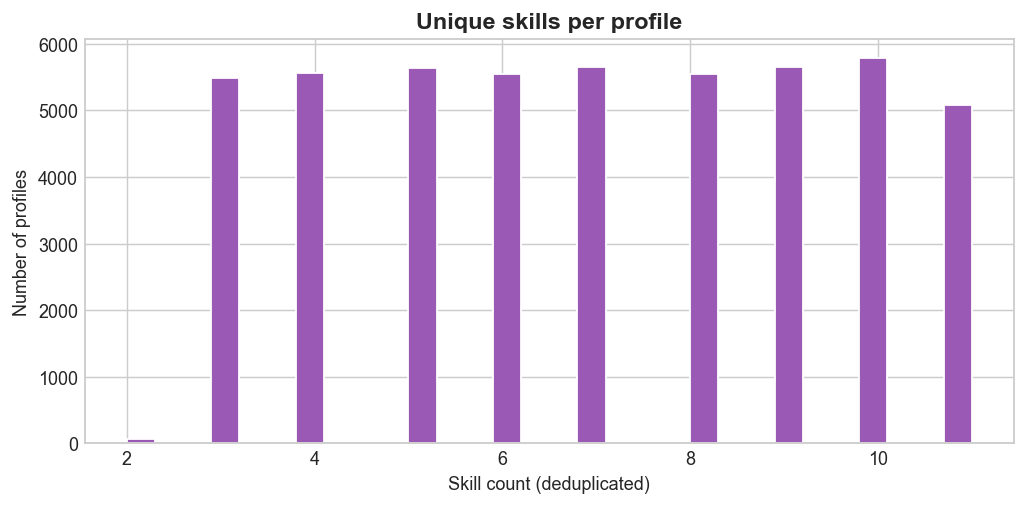

Median : 7
Mean   : 7.0
Max    : 11
Min    : 2


In [11]:
skills_per_profile = []
for val in df_original["skills"].dropna():
    parsed = safe_parse(val)
    if isinstance(parsed, list):
        unique = {s.strip().lower() for s in parsed if isinstance(s, str)}
        skills_per_profile.append(len(unique))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(skills_per_profile, bins=30, color="#9B59B6", edgecolor="white")
ax.set_title("Unique skills per profile", fontsize=13, fontweight="bold")
ax.set_xlabel("Skill count (deduplicated)")
ax.set_ylabel("Number of profiles")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "05_skills_per_profile.png"))
plt.show()

print(f"Median : {np.median(skills_per_profile):.0f}")
print(f"Mean   : {np.mean(skills_per_profile):.1f}")
print(f"Max    : {max(skills_per_profile)}")
print(f"Min    : {min(skills_per_profile)}")

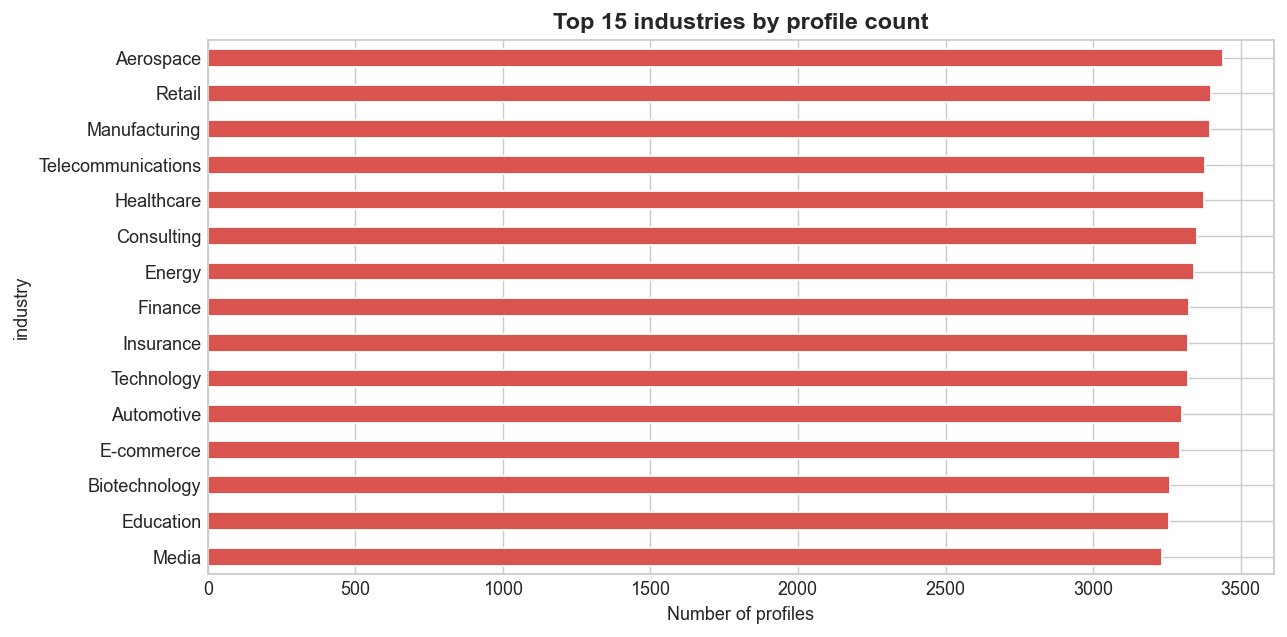

Total unique industries : 15
Null industry           : 0


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

top_industries = df_original["industry"].value_counts().head(15)
top_industries.sort_values().plot(
    kind="barh", ax=ax, color="#D9534F", edgecolor="white"
)
ax.set_title("Top 15 industries by profile count", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of profiles")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "06_industry_distribution.png"))
plt.show()

print(f"Total unique industries : {df_original['industry'].nunique()}")
print(f"Null industry           : {df_original['industry'].isna().sum()}")

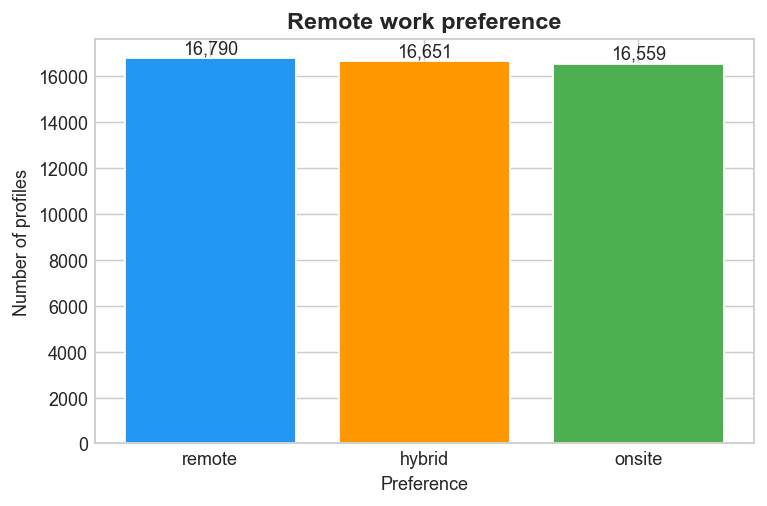

remote_preference
remote    16790
hybrid    16651
onsite    16559


In [13]:
fig, ax = plt.subplots(figsize=(6, 4))

remote_counts = df_original["remote_preference"].value_counts()
bars = ax.bar(remote_counts.index, remote_counts.values,
              color=["#2196F3", "#FF9800", "#4CAF50"],
              edgecolor="white")
for bar, val in zip(bars, remote_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 50,
            f"{val:,}", ha="center", va="bottom", fontsize=10)

ax.set_title("Remote work preference", fontsize=13, fontweight="bold")
ax.set_xlabel("Preference")
ax.set_ylabel("Number of profiles")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "07_remote_preference.png"))
plt.show()
print(remote_counts.to_string())

In [14]:
role_counts = df_original["current_role"].value_counts()
singleton_pct = 100 * (role_counts == 1).sum() / len(role_counts)

print("=== current_role cardinality ===")
print(f"Total unique roles     : {df_original['current_role'].nunique():,}")
print(f"Roles appearing once   : {(role_counts == 1).sum():,} "
      f"({singleton_pct:.1f}% of all unique roles)")
print(f"\nTop 15 most common roles:")
print(role_counts.head(15).to_string())
print(f"\nTop 15 roles cover "
      f"{100*role_counts.head(15).sum()/len(df_original):.1f}% of all profiles")
print("\n→ Keyword bucketing into 12 functional groups will be applied.")

=== current_role cardinality ===
Total unique roles     : 24
Roles appearing once   : 0 (0.0% of all unique roles)

Top 15 most common roles:
current_role
Full Stack Developer         2206
Business Analyst             2134
Frontend Developer           2133
DevOps Engineer              2111
CTO                          2109
Solutions Architect          2107
Product Manager              2095
Platform Engineer            2093
Site Reliability Engineer    2089
Systems Architect            2084
Engineering Manager          2084
Data Scientist               2083
Technical Lead               2082
ML Engineer                  2080
Software Engineer            2071

Top 15 roles cover 63.1% of all profiles

→ Keyword bucketing into 12 functional groups will be applied.


In [15]:
print("=== All unique current_role values ===")
print(df_original["current_role"].value_counts().to_string())
print(f"\nTotal unique roles: {df_original['current_role'].nunique()}")
print("\n→ Only 24 unique values — synthetic controlled vocabulary confirmed.")
print("→ Direct one-hot encoding will be applied in preprocessing.")
print("→ ROLE_BUCKETS keyword mapping is not required for this dataset.")

=== All unique current_role values ===
current_role
Full Stack Developer         2206
Business Analyst             2134
Frontend Developer           2133
DevOps Engineer              2111
CTO                          2109
Solutions Architect          2107
Product Manager              2095
Platform Engineer            2093
Site Reliability Engineer    2089
Systems Architect            2084
Engineering Manager          2084
Data Scientist               2083
Technical Lead               2082
ML Engineer                  2080
Software Engineer            2071
UI/UX Designer               2070
Scrum Master                 2068
Security Engineer            2066
Backend Developer            2061
Data Analyst                 2059
Cloud Engineer               2052
Data Engineer                2041
QA Engineer                  2036
Research Scientist           1986

Total unique roles: 24

→ Only 24 unique values — synthetic controlled vocabulary confirmed.
→ Direct one-hot encoding will be appl

In [16]:
print("=== source column — checking for signal ===")
print(df_original["source"].value_counts())
print(f"\nUnique values : {df_original['source'].nunique()}")
if df_original["source"].nunique() == 1:
    print("→ Constant column. Will be dropped in preprocessing (zero variance).")

=== source column — checking for signal ===
source
synthetic    50000
Name: count, dtype: int64

Unique values : 1
→ Constant column. Will be dropped in preprocessing (zero variance).


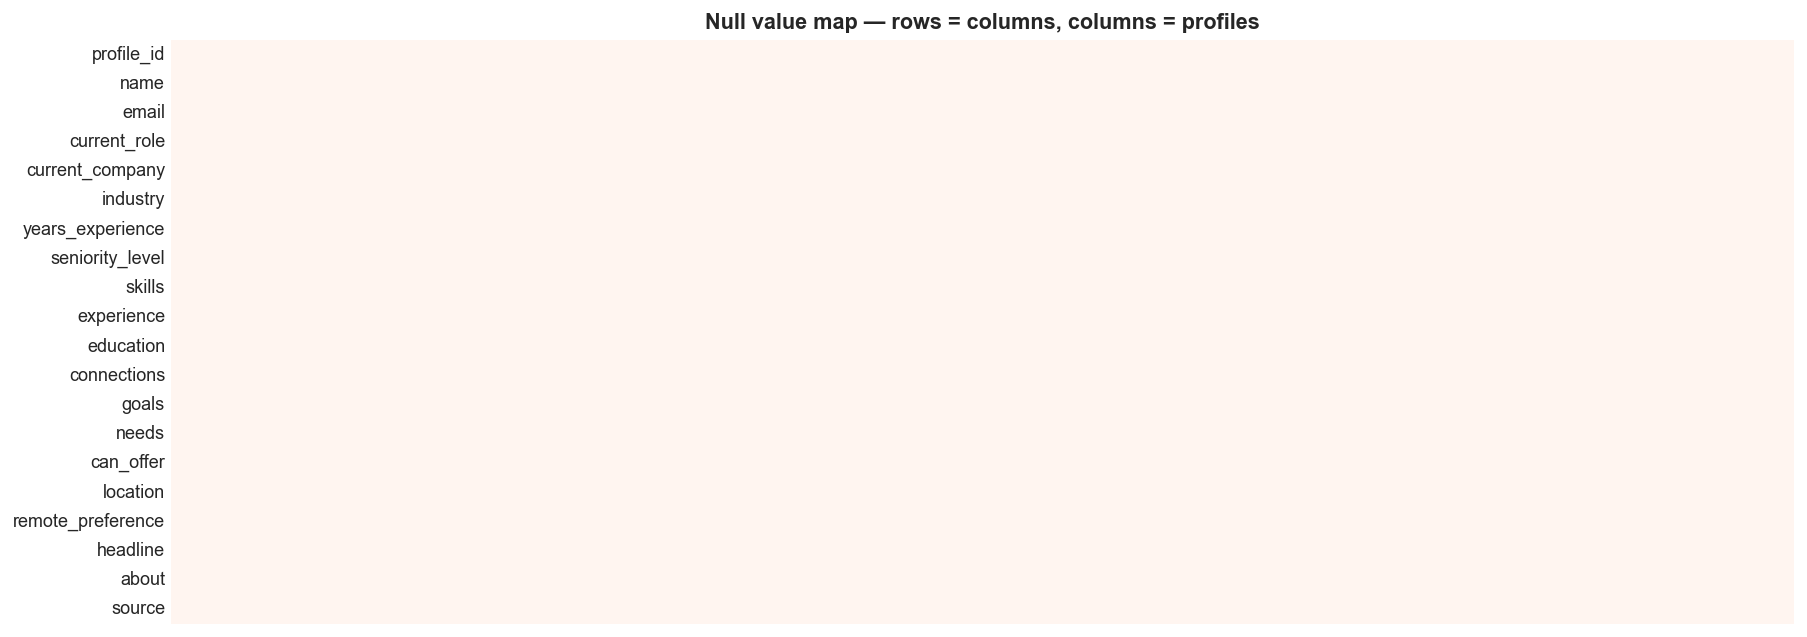

In [17]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    df_original.isnull().astype(int).T,
    ax=ax, cbar=False, cmap="Reds",
    yticklabels=df_original.columns,
    xticklabels=False
)
ax.set_title(
    "Null value map — rows = columns, columns = profiles",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "08_null_heatmap.png"))
plt.show()

## 4. EDA Summary & Preprocessing Decisions

| Observation | Preprocessing decision |
|---|---|
| `skills` uses single-quoted Python literals | `ast.literal_eval()`, not `json.loads()` |
| `skills` has duplicates within profiles | Deduplicate before multi-hot encoding |
| `experience.duration` is a string e.g. `"2 years"` | Extract integer with regex |
| `connections` is right-skewed | `log1p` before StandardScaler |
| `current_role` has only 24 unique values | Direct one-hot encoding — no bucketing needed |
| `source` is constant (`"synthetic"`) | Drop — zero variance |
| `seniority_level` has 4 clean levels | Ordinal: entry=0 … executive=3 |
| `remote_preference` has 3 clean values | Ordinal: onsite=0, hybrid=1, remote=2 |
| `headline` and `about` are boilerplate | Drop — low signal |


**Next:** `02_preprocessing.ipynb`